# Model Project: A Consumer with Two Nests

Problems 1 to 3: the model, solving it numerically, and relative prices

The model is a nested CES consumer who buys three goods: food, bus and train. Bus and train sit together in a travel nest. The model itself (utility, shares, quantities) lives in consumer.py. Here I import it and do the analysis with figures and text.

Everything is run for two calibrations that only differ in how easily bus and train can replace each other: complements (sigma_B = 0.40) and substitutes (sigma_B = 3.00).

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3d projection)

from consumer import ConsumerClass

# plotting defaults, matching the course style
plt.rcParams.update({'axes.grid':True,'grid.color':'black',
                     'grid.alpha':0.25,'grid.linestyle':'-','font.size':12})
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

The two calibrations only differ in sigma_B. I build the second model with par={'sigma_B':3.0}, so no code gets duplicated.

In [2]:
model_c = ConsumerClass()                      # complements, sigma_B = 0.40 (baseline)
model_s = ConsumerClass(par={'sigma_B':3.0})   # substitutes, sigma_B = 3.00

models = {'complements':model_c, 'substitutes':model_s}

for name,m in models.items():
    print(f'--- {name} ---'); print(m); print()

--- complements ---
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000

--- substitutes ---
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000



## 1. The model

The consumer buys three goods x1, x2, x3 >= 0 at prices p1, p2, p3 > 0 with income I > 0. Good 1 is food, goods 2 and 3 are bus and train, which sit in a travel nest.

Utility is built in two steps, one per nest. First bus and train are combined into a travel composite,
$$x_B = \left(\beta x_2^{\rho_B} + (1-\beta)x_3^{\rho_B}\right)^{1/\rho_B},$$
and then food and travel are combined into utility,
$$u(x_1,x_2,x_3) = \left(\alpha x_1^{\rho_A} + (1-\alpha)x_B^{\rho_A}\right)^{1/\rho_A},$$
with $\rho = 1-\tfrac{1}{\sigma}$. That is what utility() does: two calls to ces(), one per nest.

sigma_B is the important part here:

sigma_B < 1 (complements): bus and train go together. The consumer wants both and cannot just drop one of them.

sigma_B > 1 (substitutes): bus and train can replace each other, so the consumer mostly buys the cheaper one.

### 1.1 The problem in nested budget shares

Instead of choosing three quantities with a budget constraint, I choose two nested budget shares: s1 in [0,1] (share of income on food) and w in [0,1] (share of the travel budget on bus). The three budget shares then follow as
$$s_1,\qquad s_2=(1-s_1)w,\qquad s_3=(1-s_1)(1-w),$$
and the quantities are $x_j=s_jI/p_j$.

Why that trick is smart. Whatever (s1,w) I pick in the unit square, the three shares sum to 1, so the budget constraint holds automatically. It cannot be broken. So the constraint set is exactly the box [0,1] x [0,1], and that is what L-BFGS-B takes as bounds. No penalties, no constraint handling. It is the same idea as section 6.4 in the optimization lecture.

In [3]:
# demonstrate the (s1,w) -> shares -> quantities mapping at an arbitrary point
s1_demo, w_demo = 0.5, 0.4
for name,m in models.items():
    s1,s2,s3 = m.shares(s1_demo,w_demo)
    x1,x2,x3 = m.quantities(s1_demo,w_demo)
    u = m.value_of_choice(s1_demo,w_demo)
    print(f'{name}: (s1,s2,s3)=({s1:.3f},{s2:.3f},{s3:.3f}), sum={s1+s2+s3:.3f}, '
          f'(x1,x2,x3)=({x1:.3f},{x2:.3f},{x3:.3f}), u={u:.4f}')

complements: (s1,s2,s3)=(0.500,0.200,0.300), sum=1.000, (x1,x2,x3)=(5.000,2.000,2.000), u=3.3784
substitutes: (s1,s2,s3)=(0.500,0.200,0.300), sum=1.000, (x1,x2,x3)=(5.000,2.000,2.000), u=3.3784


The shares sum to 1 at every (s1,w), not just at the optimum. Both calibrations give the same numbers here, because I have not optimized yet. The difference only shows up once the consumer chooses optimally (section 2). Because p3 = 1.5, equal shares do not mean equal quantities: a share spent on train buys fewer trips than on the cheaper bus.

### 1.3 How do I know the answer is right?

There is no formula for the solution, so I cannot look it up. Two checks: (1) the answer is possible, meaning shares strictly in (0,1) that sum to 1 and positive quantities, and (2) two methods agree. I build check 1 as a reusable function now and use check 2 throughout section 2.

In [4]:
def check_solution(model,opt,tol=1e-6,verbose=True):
    """ check a solution is economically feasible (check 1 of section 1.3)

    Args:
        model (ConsumerClass): the solved model
        opt (SimpleNamespace): solution with .s1,.s2,.s3,.w
        tol (float): tolerance for the shares-sum-to-one test
        verbose (bool): print the outcome

    Returns:
        (bool): True if every test passes
    """

    shares_ok = all(0 < s < 1 for s in (opt.s1,opt.s2,opt.s3))   # a. inside (0,1)
    sum_ok = np.isclose(opt.s1+opt.s2+opt.s3, 1.0, atol=tol)      # b. sum to one
    x1,x2,x3 = model.quantities(opt.s1,opt.w)                     # c. quantities > 0
    quant_ok = all(x > 0 for x in (x1,x2,x3))

    ok = shares_ok and sum_ok and quant_ok
    if verbose:
        print(f'  shares in (0,1): {shares_ok} | sum to one: {sum_ok} '
              f'({opt.s1+opt.s2+opt.s3:.8f}) | quantities > 0: {quant_ok} => '
              f'{"PASS" if ok else "FAIL"}')
    return ok

## 2. Solving the model numerically

I solve the same problem two ways, grid search and L-BFGS-B, and check that they agree.

### 2.1.1 Grid search: find the optimum

Grid search lays an N x N grid over the unit square, computes utility at every (s1,w), and keeps the best point. Every point in the square is a valid choice, so there is nothing to mask out, an argmax is enough. That is solve_grid().

In [5]:
grid = {}
for name,m in models.items():
    grid[name] = m.solve_grid(N=500,do_print=True)
    check_solution(m,grid[name])
    print()

grid search (N=500): s1=0.5351, w=0.4389 -> (s1,s2,s3)=(0.5351,0.2040,0.2609), u=3.401674
  shares in (0,1): True | sum to one: True (1.00000000) | quantities > 0: True => PASS

grid search (N=500): s1=0.5391, w=0.6914 -> (s1,s2,s3)=(0.5391,0.3187,0.1422), u=3.485097
  shares in (0,1): True | sum to one: True (1.00000000) | quantities > 0: True => PASS



Both solutions are feasible. The economic difference shows up now: in substitutes the consumer puts more of the travel budget on bus (higher w), because bus and train can replace each other and bus is cheapest (p2 = 1.0 < p3 = 1.5). In complements the consumer keeps a more even split, because train cannot just be dropped.

### 2.1.2 Grid search: plot the utility surface

I plot utility over (s1,w) as a 3D surface and as a contour, with the grid optimum marked, for both calibrations.

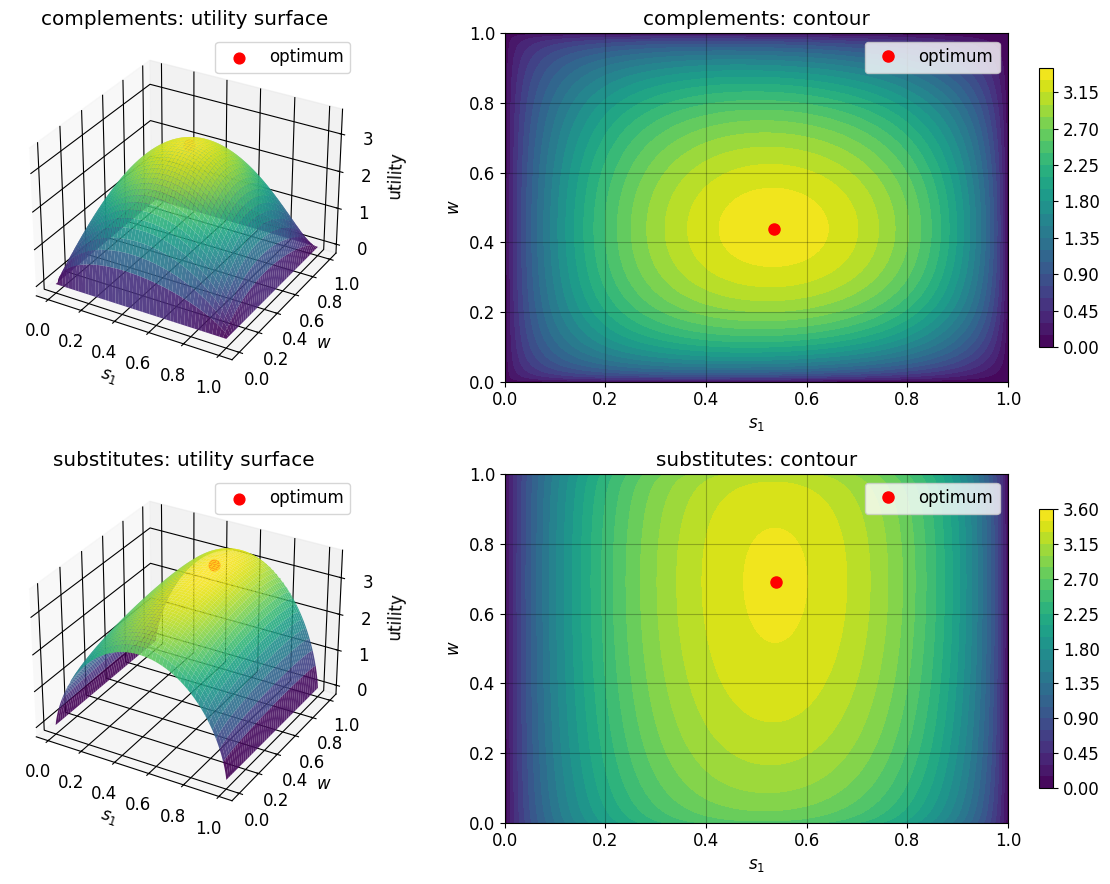

In [6]:
fig = plt.figure(figsize=(13,9))
for row,(name,m) in enumerate(models.items()):
    opt = grid[name]

    # a. 3D surface
    ax = fig.add_subplot(2,2,2*row+1,projection='3d')
    ax.plot_surface(opt.s1_grid,opt.w_grid,opt.u_grid,cmap='viridis',alpha=0.9)
    ax.scatter(opt.s1,opt.w,opt.u,color='red',s=60,label='optimum')
    ax.set_xlabel('$s_1$'); ax.set_ylabel('$w$'); ax.set_zlabel('utility')
    ax.set_title(f'{name}: utility surface')
    ax.legend()

    # b. contour
    ax = fig.add_subplot(2,2,2*row+2)
    cs = ax.contourf(opt.s1_grid,opt.w_grid,opt.u_grid,levels=30,cmap='viridis')
    ax.plot(opt.s1,opt.w,'ro',ms=8,label='optimum')
    ax.set_xlabel('$s_1$'); ax.set_ylabel('$w$')
    ax.set_title(f'{name}: contour'); ax.legend()
    fig.colorbar(cs,ax=ax,shrink=0.8)

fig.tight_layout()
plt.show()

The optimum sits inside the square in both cases. The contour spacing already shows what section 2.1.4 asks about: the surface is more peaked in one calibration than the other.

### 2.1.3 Grid search: does more resolution help?

I run grid search for N = 50, 100, 500, 1000 and record the optimum, utility, and number of utility evaluations (N squared).

In [7]:
N_list = [50,100,500,1000]
for name,m in models.items():
    print(f'=== {name} ===')
    print(f'{"N":>6} {"s1":>10} {"w":>10} {"utility":>12} {"evals":>10}')
    for N in N_list:
        o = m.solve_grid(N=N,do_print=False)
        print(f'{N:>6} {o.s1:>10.5f} {o.w:>10.5f} {o.u:>12.7f} {o.n_eval:>10}')
    print()

=== complements ===
     N         s1          w      utility      evals
    50    0.53061    0.44898    3.4007477       2500
   100    0.53535    0.44444    3.4014822      10000
   500    0.53507    0.43888    3.4016744     250000


  1000    0.53554    0.43944    3.4016798    1000000

=== substitutes ===
     N         s1          w      utility      evals
    50    0.53061    0.69388    3.4845944       2500
   100    0.53535    0.69697    3.4850049      10000
   500    0.53908    0.69138    3.4850971     250000
  1000    0.53854    0.69269    3.4851035    1000000



Utility barely changes after N = 100. The gain from a finer grid shrinks quickly while the cost grows as N squared (from 2,500 to 1,000,000 evaluations). (s1,w) keeps moving a bit in the last decimals, because a grid can only land on its own points, so the improvement is not perfectly smooth. That is the weakness of grid search: to halve the error N has to roughly double, which quadruples the cost. That is the reason to use the gradient based method in 2.2.

### 2.1.4 Grid search: compare the calibrations

Which calibration is harder for an optimizer? I look at the full contour plots from 2.1.2, and add a slice through the optimum as a supporting view.

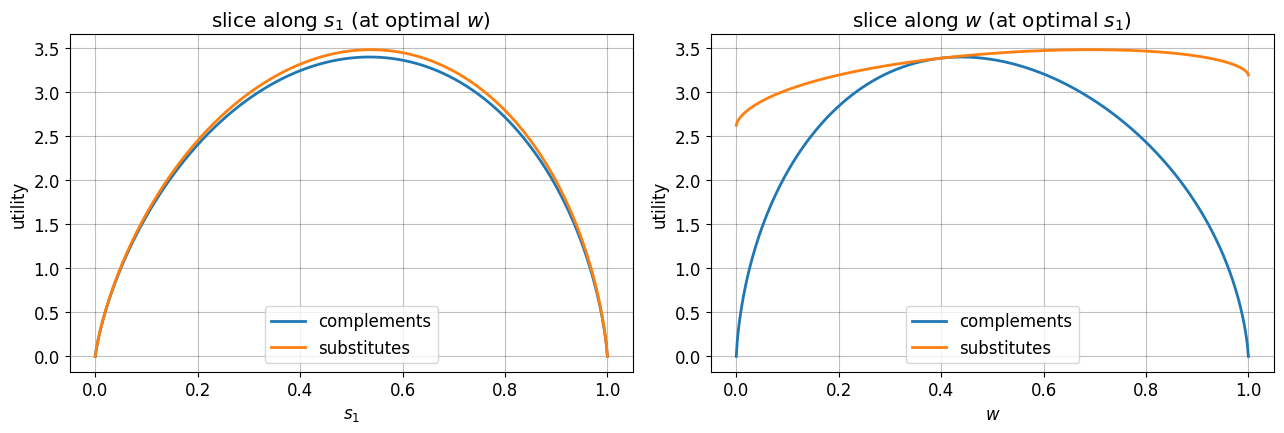

In [8]:
fig,axes = plt.subplots(1,2,figsize=(13,4.5))

# a. slice in s1 at the optimal w
ax = axes[0]
for name,m in models.items():
    o = grid[name]
    j = np.argmin(np.abs(o.w_grid[0,:]-o.w))   # column nearest optimal w
    ax.plot(o.s1_grid[:,j],o.u_grid[:,j],label=name,lw=2)
ax.set_xlabel('$s_1$'); ax.set_ylabel('utility'); ax.set_title('slice along $s_1$ (at optimal $w$)')
ax.legend()

# b. slice in w at the optimal s1
ax = axes[1]
for name,m in models.items():
    o = grid[name]
    i = np.argmin(np.abs(o.s1_grid[:,0]-o.s1))  # row nearest optimal s1
    ax.plot(o.w_grid[i,:],o.u_grid[i,:],label=name,lw=2)
ax.set_xlabel('$w$'); ax.set_ylabel('utility'); ax.set_title('slice along $w$ (at optimal $s_1$)')
ax.legend()

fig.tight_layout(); plt.show()

Looking at the full contour plots, the substitutes case is the flatter one. Its top is a long, shallow ridge: because bus and train are close substitutes, many combinations of w give almost the same utility, so the contour lines are widely spaced along that ridge. The complements case is more sharply peaked, with contour lines packed tightly around the optimum in both directions.

The w slice through the optimum can be misleading here, because it only shows one direction. Along w the complements surface does look flat, but that is just one axis. Across the whole square the substitutes surface has the flatter region, and that is what matters for the optimizer. A flat ridge gives weak gradient information along its length, so I expect the substitutes calibration to be the harder one to pin down precisely, even though both solve fine in practice.

## 2.2 L-BFGS-B

### 2.2.1 Solve the model

L-BFGS-B is the workhorse from the course for smooth problems with few variables and simple bounds. Because the problem is written in shares, the bounds ((0,1),(0,1)) are the whole constraint set. I minimize objective, which is minus u (a minimizer minimizes, I maximize). I compare solution, evaluations and runtime with the grid.

In [9]:
for name,m in models.items():
    # grid timing
    t0 = time.perf_counter(); g = m.solve_grid(N=500,do_print=False); t_grid = time.perf_counter()-t0
    # L-BFGS-B timing
    t0 = time.perf_counter(); o = m.solve(do_print=False); t_opt = time.perf_counter()-t0

    print(f'=== {name} ===')
    print(f'  grid   : s1={g.s1:.5f}, w={g.w:.5f}, u={g.u:.7f}, evals={g.n_eval:>8}, {t_grid*1e3:7.1f} ms')
    print(f'  L-BFGS-B: s1={o.s1:.5f}, w={o.w:.5f}, u={o.u:.7f}, evals={o.nfev:>8}, {t_opt*1e3:7.1f} ms')
    print(f'  agree on utility: {np.isclose(g.u,o.u,atol=1e-4)}')
    check_solution(m,o)
    print()

=== complements ===
  grid   : s1=0.53507, w=0.43888, u=3.4016744, evals=  250000,    16.0 ms
  L-BFGS-B: s1=0.53562, w=0.43948, u=3.4016799, evals=      18,     2.9 ms
  agree on utility: True
  shares in (0,1): True | sum to one: True (1.00000000) | quantities > 0: True => PASS

=== substitutes ===
  grid   : s1=0.53908, w=0.69138, u=3.4850971, evals=  250000,    10.8 ms
  L-BFGS-B: s1=0.53823, w=0.69231, u=3.4851046, evals=      27,     2.8 ms
  agree on utility: True
  shares in (0,1): True | sum to one: True (1.00000000) | quantities > 0: True => PASS



The two methods agree to four decimals, but L-BFGS-B hits the answer in a few dozen evaluations against the grid's 250,000. Much cheaper and faster. That is check 2 from section 1.3, passed for both calibrations.

### 2.2.2 Record the convergence path

solve() stores every point the optimizer visits (via a callback) in opt.path. I draw the path on the contour plot and plot the distance to the final solution against the iteration number on a log scale.

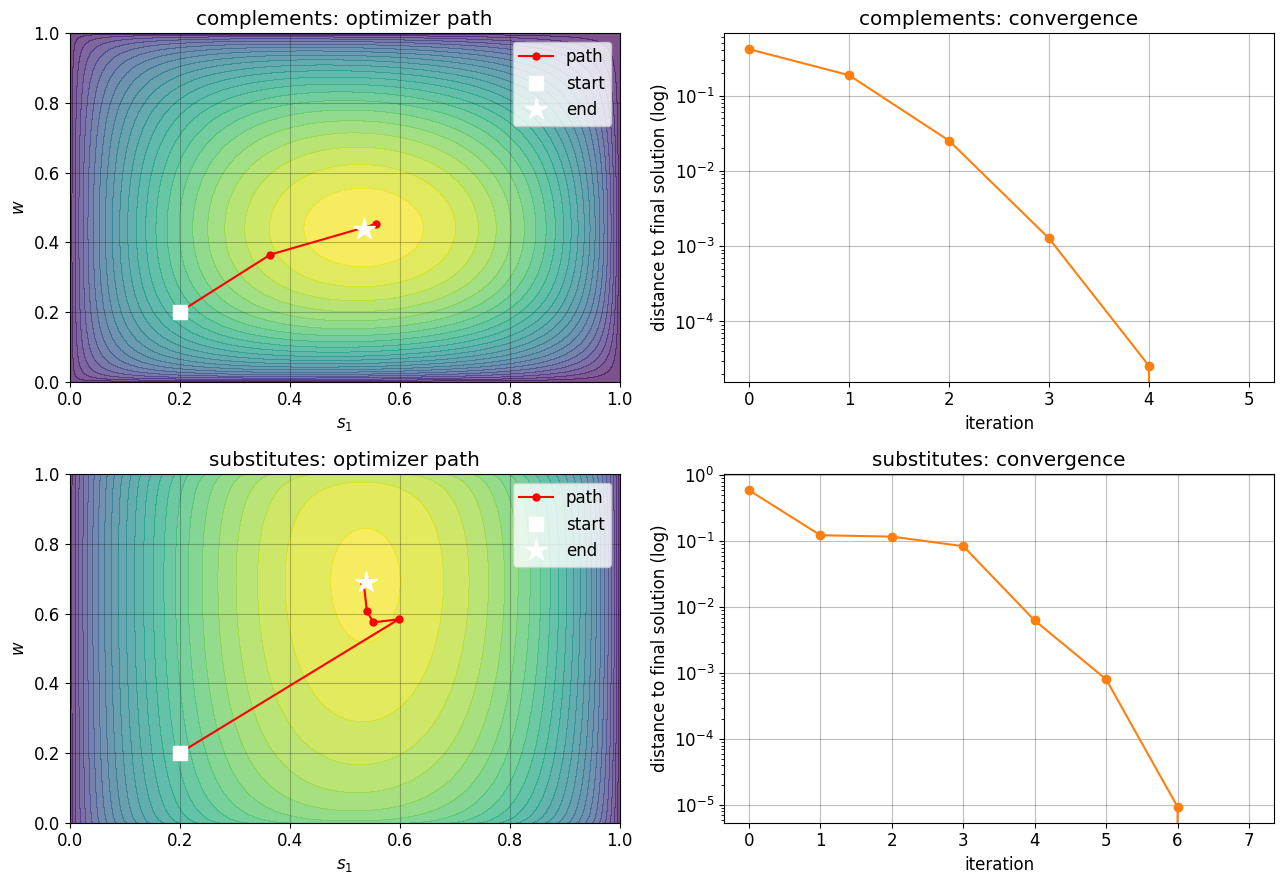

In [10]:
fig = plt.figure(figsize=(13,9))
for row,(name,m) in enumerate(models.items()):
    o = m.solve(s0=[0.2,0.2],do_print=False)   # start away from the optimum to see movement
    path = o.path
    final = path[-1]

    # a. path on the contour
    ax = fig.add_subplot(2,2,2*row+1)
    g = grid[name]
    ax.contourf(g.s1_grid,g.w_grid,g.u_grid,levels=30,cmap='viridis',alpha=0.7)
    ax.plot(path[:,0],path[:,1],'o-',color='red',ms=5,lw=1.5,label='path')
    ax.plot(path[0,0],path[0,1],'ws',ms=10,label='start')
    ax.plot(path[-1,0],path[-1,1],'w*',ms=16,label='end')
    ax.set_xlabel('$s_1$'); ax.set_ylabel('$w$')
    ax.set_title(f'{name}: optimizer path'); ax.legend()

    # b. distance to final solution vs iteration
    ax = fig.add_subplot(2,2,2*row+2)
    dist = np.linalg.norm(path-final,axis=1)
    ax.semilogy(range(len(dist)),dist,'o-',color=colors[1])
    ax.set_xlabel('iteration'); ax.set_ylabel('distance to final solution (log)')
    ax.set_title(f'{name}: convergence')

fig.tight_layout(); plt.show()

The log scale is the useful part here. The distance to the final solution falls in a roughly straight line on the log axis, which means each iteration cuts the remaining distance by about the same factor. That is linear convergence, and it is what L-BFGS-B typically shows on a smooth problem like this: it builds an approximation of the curvature from past steps and uses it to take well-scaled steps toward the optimum. The first few iterations cover most of the distance because the gradient is large and informative far from the top. As it gets close the gradient shrinks, the steps get smaller, and the line flattens into the numerical floor, where the remaining distance is down at the tolerance level and further iterations buy almost nothing.

### 2.2.3 Starting points

I solve from six starting points, the center, the four corners, and one extra, and record what happens for each. The problem warns that one corner fails in one calibration even though success=True. I find it and explain.

In [11]:
starts = {'center':[0.5,0.5],'corner (0,0)':[0,0],'corner (0,1)':[0,1],
          'corner (1,0)':[1,0],'corner (1,1)':[1,1],'extra (0.2,0.8)':[0.2,0.8]}

for name,m in models.items():
    u_true = m.solve_grid(N=1000,do_print=False).u
    print(f'=== {name} (grid utility ~ {u_true:.5f}) ===')
    print(f'{"start":>16} {"s1":>9} {"w":>9} {"utility":>11} {"nit":>5} {"nfev":>6} {"success":>8}  flag')
    for lbl,s0 in starts.items():
        o = m.solve(s0=s0,do_print=False)
        stuck = '  <-- STUCK at u=0' if abs(o.u-u_true)>1e-3 else ''
        print(f'{lbl:>16} {o.s1:>9.4f} {o.w:>9.4f} {o.u:>11.5f} {o.nit:>5} {o.nfev:>6} '
              f'{str(o.res.success):>8}{stuck}')
    print()

=== complements (grid utility ~ 3.40168) ===
           start        s1         w     utility   nit   nfev  success  flag
          center    0.5356    0.4395     3.40168     4     18     True
    corner (0,0)    0.5356    0.4395     3.40168     7     27     True
    corner (0,1)    0.5356    0.4395     3.40168     9     33     True
    corner (1,0)    1.0000    0.0000     0.00000     1     21     True  <-- STUCK at u=0
    corner (1,1)    1.0000    1.0000     0.00000     1     21     True  <-- STUCK at u=0
 extra (0.2,0.8)    0.5356    0.4395     3.40168     6     27     True

=== substitutes (grid utility ~ 3.48510) ===
           start        s1         w     utility   nit   nfev  success  flag
          center    0.5382    0.6923     3.48510     6     27     True
    corner (0,0)    0.5382    0.6923     3.48510    18     72     True
    corner (0,1)    0.5382    0.6923     3.48510    17     66     True
    corner (1,0)    0.5382    0.6923     3.48510    18     81     True
    corne

In substitutes all starting points reach the same optimum. In complements the two starting points with s1 = 1, corner (1,0) and (1,1), stop after a single iteration far from the optimum, but still report success=True.

Why. At s1 = 1 the consumer spends everything on food, so x2 = x3 = 0 and the travel composite is zero. To keep z**rho defined when rho < 0, ces() floors its inputs at par.s_min = 1e-12, so utility at the corner is not exactly zero but a tiny number around 1e-11. The real problem is the gradient, not the level. Along the s1 = 1 edge utility stays almost constant against that floor, so when L-BFGS-B estimates the gradient with its small finite-difference step (eps, about 1e-8), both the base point and the stepped point land on essentially the same floored value. The estimated gradient comes out near zero, the solver reads that as no direction of improvement, takes no step, and reports success. It is a failure of gradient estimation at the boundary, not a true local minimum.

With substitutes bus alone can stand in for train, so the composite stays well above the floor, the estimated gradient points inward, and every starting point escapes. The point: success=True only means the optimizer stopped cleanly, and here it stopped on a flat boundary where the estimated gradient was numerically zero. That is exactly why I solve from several starting points and cross check against the grid.

### 2.2.4 Numerical tolerances

I vary the objective tolerance ftol and the gradient tolerance gtol, and report the two shares, utility, and number of evaluations for each setting. Both go in options={...}.

In [12]:
ftols = [1e-4,1e-8,1e-12,1e-16]
gtols = [1e-2,1e-5,1e-8,1e-12]

for name,m in models.items():
    print(f'=== {name} ===')
    print('(a) varying ftol (gtol at default)')
    print(f'{"ftol":>8} {"s1":>10} {"w":>10} {"utility":>13} {"nfev":>6}')
    for ftol in ftols:
        o = m.solve(do_print=False,options={'ftol':ftol})
        print(f'{ftol:>8.0e} {o.s1:>10.6f} {o.w:>10.6f} {o.u:>13.9f} {o.nfev:>6}')
    print('(b) varying gtol (ftol at default)')
    print(f'{"gtol":>8} {"s1":>10} {"w":>10} {"utility":>13} {"nfev":>6}')
    for gtol in gtols:
        o = m.solve(do_print=False,options={'gtol':gtol})
        print(f'{gtol:>8.0e} {o.s1:>10.6f} {o.w:>10.6f} {o.u:>13.9f} {o.nfev:>6}')
    print()

=== complements ===
(a) varying ftol (gtol at default)
    ftol         s1          w       utility   nfev
   1e-04   0.535607   0.439652   3.401679632     15
   1e-08   0.535623   0.439479   3.401679876     18
   1e-12   0.535623   0.439479   3.401679876     18
   1e-16   0.535623   0.439479   3.401679876     18
(b) varying gtol (ftol at default)
    gtol         s1          w       utility   nfev
   1e-02   0.535607   0.439652   3.401679632     15
   1e-05   0.535623   0.439479   3.401679876     18
   1e-08   0.535624   0.439478   3.401679876     21
   1e-12   0.535624   0.439478   3.401679876     21

=== substitutes ===
(a) varying ftol (gtol at default)
    ftol         s1          w       utility   nfev
   1e-04   0.538155   0.691562   3.485103847     21
   1e-08   0.538225   0.692308   3.485104590     27
   1e-12   0.538225   0.692308   3.485104590     27
   1e-16   0.538225   0.692308   3.485104590     27
(b) varying gtol (ftol at default)
    gtol         s1          w       ut

A tighter tolerance gives more precision at first and then stops mattering: past a certain point the shares and utility no longer change while the number of evaluations keeps rising. Beyond about ftol=1e-12 the optimizer is chasing changes smaller than floating point noise (see the floating point lecture), so more evaluations give nothing.

### 2.2.5 Which settings would I use?

I do not know the analytical answer, but because the model maximizes utility, higher utility means a better numerical solution, so I can rank settings by the utility they reach, weighed against the cost.

In [13]:
print(f'{"calibration":>12} {"ftol":>8} {"utility":>13} {"nfev":>6}')
for name,m in models.items():
    for ftol in [1e-4,1e-8,1e-12,1e-16]:
        o = m.solve(do_print=False,options={'ftol':ftol})
        print(f'{name:>12} {ftol:>8.0e} {o.u:>13.9f} {o.nfev:>6}')

 calibration     ftol       utility   nfev
 complements    1e-04   3.401679632     15
 complements    1e-08   3.401679876     18
 complements    1e-12   3.401679876     18
 complements    1e-16   3.401679876     18
 substitutes    1e-04   3.485103847     21
 substitutes    1e-08   3.485104590     27
 substitutes    1e-12   3.485104590     27
 substitutes    1e-16   3.485104590     27


A tighter tolerance is not automatically better. Once utility has stopped improving, a smaller ftol just gives more evaluations (and runtime) for a solution that is the same to nine decimals. The sensible choice is the loosest tolerance that still reaches the best utility, here around ftol=1e-8 to 1e-10. It lands on the same optimum as the tightest setting but at a fraction of the cost. Tighter than that spends time resolving noise instead of economics.

## 3. Relative prices and demand

Now I use the model. Train tickets get more expensive and I look at what the consumer does. Everything reuses the two calibrations built in the setup above.

### 3.1 Vary the train price

I vary p3 over [0.5, 3.0] while keeping p1, p2 and I fixed. For every p3 I update the price, solve the model, and store the three budget shares and the three quantities. I reuse the same object and just change model.par.p3 in a loop, so nothing is duplicated.

In [14]:
N = 100
p3_grid = np.linspace(0.5,3.0,N)

# store results per calibration: shares (s1,s2,s3) and quantities (x1,x2,x3)
results = {}
for name,m in models.items():
    shares = np.zeros((N,3))
    quants = np.zeros((N,3))
    for i,p3 in enumerate(p3_grid):
        m.par.p3 = p3                    # a. update the price
        o = m.solve(do_print=False)      # b. solve at this price
        shares[i] = [o.s1,o.s2,o.s3]     # c. store budget shares
        quants[i] = m.quantities(o.s1,o.w)  # d. store quantities
    m.par.p3 = 1.5                       # reset to baseline afterwards
    results[name] = {'shares':shares,'quants':quants}

print('done, stored shares and quantities for', N, 'prices in each calibration')

done, stored shares and quantities for 100 prices in each calibration


Now I plot the budget shares and the quantities against p3, both calibrations.

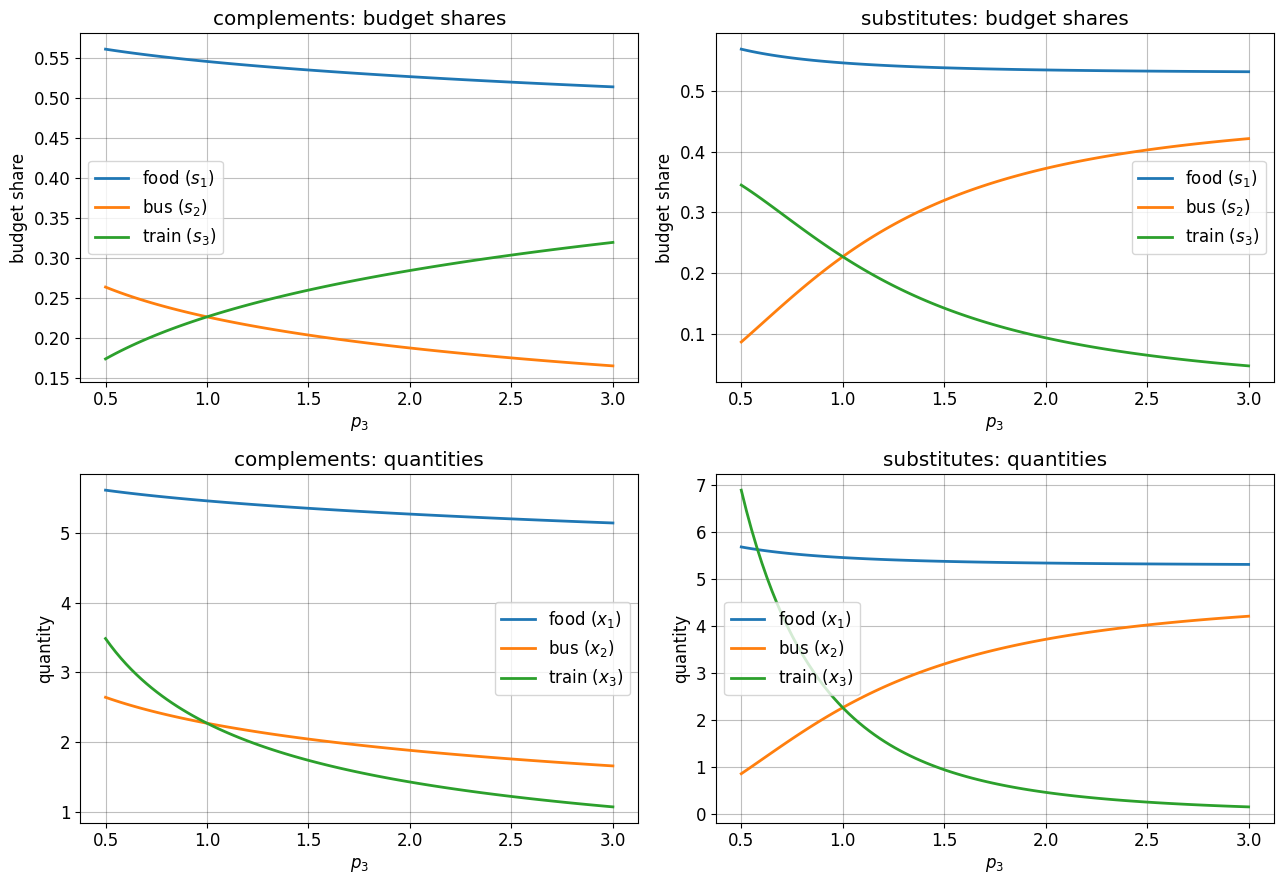

In [15]:
fig,axes = plt.subplots(2,2,figsize=(13,9))
labels = ['food ($s_1$)','bus ($s_2$)','train ($s_3$)']
qlabels = ['food ($x_1$)','bus ($x_2$)','train ($x_3$)']

for col,(name,m) in enumerate(models.items()):
    sh = results[name]['shares']
    qt = results[name]['quants']

    # top row: budget shares
    ax = axes[0,col]
    for k in range(3):
        ax.plot(p3_grid,sh[:,k],label=labels[k],lw=2)
    ax.set_xlabel('$p_3$'); ax.set_ylabel('budget share')
    ax.set_title(f'{name}: budget shares'); ax.legend()

    # bottom row: quantities
    ax = axes[1,col]
    for k in range(3):
        ax.plot(p3_grid,qt[:,k],label=qlabels[k],lw=2)
    ax.set_xlabel('$p_3$'); ax.set_ylabel('quantity')
    ax.set_title(f'{name}: quantities'); ax.legend()

fig.tight_layout(); plt.show()

### 3.2 What happens to the train share?

The question is about the budget share s3 = p3*x3/I, so I look at the slope of the s3 curve against p3 in each calibration.

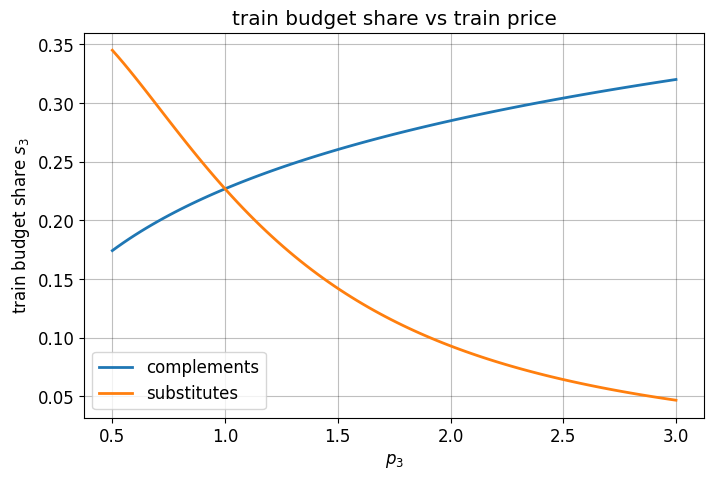

complements: s3 goes from 0.1742 at p3=0.5 to 0.3200 at p3=3.0
substitutes: s3 goes from 0.3449 at p3=0.5 to 0.0468 at p3=3.0


In [16]:
fig,ax = plt.subplots(figsize=(8,5))
for name,m in models.items():
    s3 = results[name]['shares'][:,2]
    ax.plot(p3_grid,s3,label=name,lw=2)
ax.set_xlabel('$p_3$'); ax.set_ylabel('train budget share $s_3$')
ax.set_title('train budget share vs train price'); ax.legend()
plt.show()

for name,m in models.items():
    s3 = results[name]['shares'][:,2]
    print(f'{name}: s3 goes from {s3[0]:.4f} at p3=0.5 to {s3[-1]:.4f} at p3=3.0')

In complements a higher p3 raises the train budget share, and in substitutes it lowers it.

The reason is the substitution between bus and train. In complements the consumer wants a roughly fixed mix of bus and train and cannot drop the train, so demand is inelastic: when p3 rises, x3 falls only a little, and p3*x3 (so s3) still goes up. In substitutes the consumer switches to bus when train gets expensive, so x3 falls sharply, and the fall in x3 outweighs the higher price, so s3 goes down.

### 3.3 Bus demand

Here the question is about the quantity of bus trips x2, not the bus share. I reuse the stored quantities from 3.1.

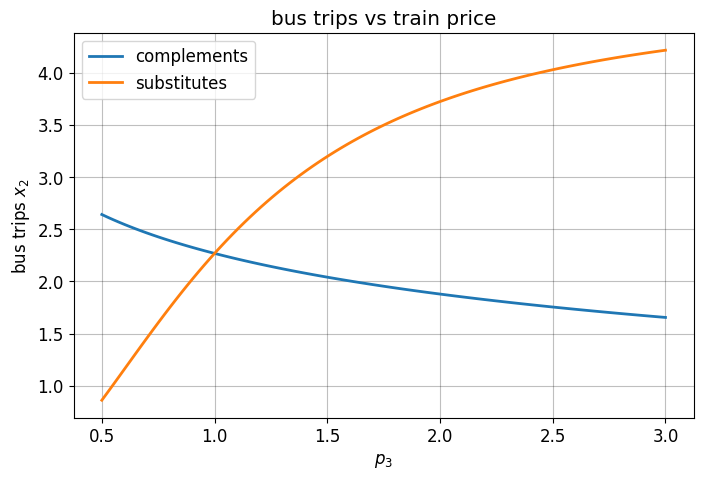

complements: x2 goes from 2.641 at p3=0.5 to 1.655 at p3=3.0
substitutes: x2 goes from 0.862 at p3=0.5 to 4.215 at p3=3.0


In [17]:
fig,ax = plt.subplots(figsize=(8,5))
for name,m in models.items():
    x2 = results[name]['quants'][:,1]
    ax.plot(p3_grid,x2,label=name,lw=2)
ax.set_xlabel('$p_3$'); ax.set_ylabel('bus trips $x_2$')
ax.set_title('bus trips vs train price'); ax.legend()
plt.show()

for name,m in models.items():
    x2 = results[name]['quants'][:,1]
    print(f'{name}: x2 goes from {x2[0]:.3f} at p3=0.5 to {x2[-1]:.3f} at p3=3.0')

The two calibrations pull in opposite directions. In substitutes bus and train are interchangeable, so when train gets more expensive the consumer moves onto the bus and x2 rises a lot. In complements bus and train are used together, so a higher train price drags bus demand down slightly as well, because the consumer buys less travel overall. This is the core economic difference: substitutes shift demand between the two travel goods, complements move them in the same direction.

### 3.4 Food versus bus demand

Now I compare how much the train price changes food demand x1 against bus demand x2, on a common x axis.

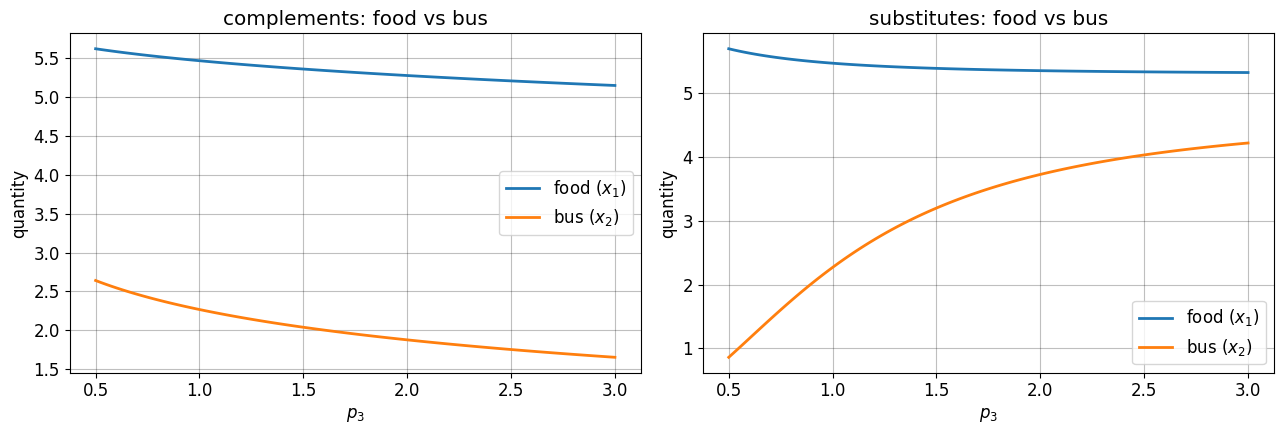

complements: change in food = -0.471, change in bus = -0.986
substitutes: change in food = -0.372, change in bus = +3.353


In [18]:
fig,axes = plt.subplots(1,2,figsize=(13,4.5),sharex=True)
for col,(name,m) in enumerate(models.items()):
    qt = results[name]['quants']
    ax = axes[col]
    ax.plot(p3_grid,qt[:,0],label='food ($x_1$)',lw=2)
    ax.plot(p3_grid,qt[:,1],label='bus ($x_2$)',lw=2)
    ax.set_xlabel('$p_3$'); ax.set_ylabel('quantity')
    ax.set_title(f'{name}: food vs bus'); ax.legend()
fig.tight_layout(); plt.show()

for name,m in models.items():
    qt = results[name]['quants']
    dx1 = qt[-1,0]-qt[0,0]
    dx2 = qt[-1,1]-qt[0,1]
    print(f'{name}: change in food = {dx1:+.3f}, change in bus = {dx2:+.3f}')

Food demand barely moves in either calibration, while bus demand changes a lot. That tells me the train price mainly changes the allocation inside the travel nest, between bus and train, and does very little to the split between food and travel in the upper nest. The nested structure is what produces this: p3 lives inside the travel nest, so it first reshuffles bus against train, and only reaches food indirectly through the travel composite, where the effect is small.

## 4. Lump-sum taxes and product taxes

The government has two instruments. A lump-sum tax `T` lowers income from `I` to
`I-T`. A product tax `tau_j >= 0` raises the price the consumer pays for good `j`
from `p_j` to `(1+tau_j)*p_j`, while the seller still receives `p_j`. Total revenue
is eq. 5,

$$R = T + \sum_{j=1}^{3}\tau_j p_j x_j^{\star},$$

where `x_j` is what the consumer buys given* the taxes. The revenue leaves the
model: the consumer gets nothing back.

### 4.1 Implementing the revenue equation

`GovernmentClass` inherits everything from `ConsumerClass`, so the whole of
sections 1-3 keeps working. Two methods do the work:

* `set_taxes(T,tau1,tau2,tau3)` writes the taxes into `par`, sets the prices the
  consumer faces to `(1+tau_j)*p_j_pre`, and sets income to `I_pre - T`. After
  this call, `solve()`, `shares()` and `quantities()` all describe the situation
  with taxes, without a single change to the code from sections 1-3.
* `tax_revenue(opt)` evaluates eq. 5 at the solution `opt`: it converts the nested
  shares `(s1,w)` into quantities and adds up `T` plus `tau_jp_j_prex_j`.

The one thing worth being careful about is which price enters eq. 5. The `p_j` in
eq. 5 is the price the seller receives, i.e. the price before the tax was added
 which is why `sync_pre_tax()` stores `p1_pre, p2_pre, p3_pre, I_pre` at
construction time, and why `tax_revenue()` uses those and not `par.p1, par.p2,
par.p3`. Using the post-tax prices would count the tax rate twice and overstate
revenue by a factor `(1+tau_j)`.

`tax_revenue()` takes an already-solved `opt` as an argument. That is not
cosmetic: solving the consumer's problem is the expensive step, and in sections
4.2-4.5 we need revenue and utility from the same solution. Passing `opt` in
guarantees the two numbers describe the same consumer, and halves the work.

In [19]:
# problem 4 also needs the government, which inherits from the consumer
from Government import GovernmentClass

In [20]:
# the two calibrations, exactly as in sections 1-3, but now as governments
gov = {}
gov['complements'] = GovernmentClass()                    # sigma_B = 0.40
gov['substitutes'] = GovernmentClass(par={'sigma_B':3.0}) # sigma_B = 3.00

for name,model in gov.items():
    par = model.par
    print(f'{name}: p1_pre={par.p1_pre:.4f}, p2_pre={par.p2_pre:.4f}, '
          f'p3_pre={par.p3_pre:.4f}, I_pre={par.I_pre:.4f}')

complements: p1_pre=1.0000, p2_pre=1.0000, p3_pre=1.5000, I_pre=10.0000
substitutes: p1_pre=1.0000, p2_pre=1.0000, p3_pre=1.5000, I_pre=10.0000


In [21]:
# with all taxes at zero the consumer's problem is the one from section 2,
# and eq. 5 must give exactly zero
for name,model in gov.items():
    model.set_taxes()
    opt = model.solve(do_print=False)
    R = model.tax_revenue(opt)
    print(f'{name}: R={R:.10f}, u={opt.u:.6f}')
    assert np.isclose(R,0.0), 'no taxes must give no revenue'

complements: R=0.0000000000, u=3.401680
substitutes: R=0.0000000000, u=3.485105


In [22]:
# a tax on the bus only: eq. 5 collapses to a single term, tau2*p2_pre*x2,
# which we can compute by hand and compare with what tax_revenue() returns
for name,model in gov.items():
    model.set_taxes(tau2=0.5)
    opt = model.solve(do_print=False)
    x1,x2,x3 = model.quantities(opt.s1,opt.w)
    R = model.tax_revenue(opt)
    R_hand = 0.5*model.par.p2_pre*x2
    print(f'{name}: x=({x1:.4f},{x2:.4f},{x3:.4f}), '
          f'R={R:.6f}, by hand={R_hand:.6f}')
    assert np.isclose(R,R_hand)

complements: x=(5.2614,1.5795,1.5795), R=0.789769, by hand=0.789769
substitutes: x=(5.2614,1.5795,1.5795), R=0.789769, by hand=0.789769


In [23]:
# an accounting identity that must hold for any combination of taxes:
# the consumer spends I-T at the prices he pays, and revenue is the lump-sum
# tax plus the wedge between what he pays and what the sellers receive
for name,model in gov.items():
    model.set_taxes(T=0.5,tau1=0.2,tau2=0.5,tau3=1.0)
    opt = model.solve(do_print=False)
    par = model.par

    # a. quantities at the taxed prices
    x1,x2,x3 = model.quantities(opt.s1,opt.w)

    # b. spending at consumer prices and at seller prices
    spend_consumer = par.p1*x1 + par.p2*x2 + par.p3*x3
    spend_seller = par.p1_pre*x1 + par.p2_pre*x2 + par.p3_pre*x3

    # c. the two identities
    R = model.tax_revenue(opt)
    print(f'{name}: spending={spend_consumer:.6f}, I-T={par.I_pre-par.T:.6f}, '
          f'R={R:.6f}, T+wedge={par.T+spend_consumer-spend_seller:.6f}')
    assert np.isclose(spend_consumer,par.I_pre-par.T)
    assert np.isclose(R,par.T+spend_consumer-spend_seller)

complements: spending=9.500000, I-T=9.500000, R=3.310988, T+wedge=3.310988
substitutes: spending=9.500000, I-T=9.500000, R=2.988663, T+wedge=2.988663


In [24]:
# the same rate on all three goods scales every price by (1+tau), which is the
# same as scaling income by 1/(1+tau). The consumer's real problem is unchanged,
# spending at seller prices is I/(1+tau), and revenue must be exactly
# R = tau/(1+tau)*I -- the only closed-form answer available in this model
for name,model in gov.items():
    for tau in [0.25,0.5,1.0,2.0]:
        R,u = model.revenue_and_utility(tau,goods=(1,2,3))
        R_formula = tau/(1+tau)*model.par.I_pre
        print(f'{name}, tau={tau:.2f}: R={R:.8f}, formula={R_formula:.8f}')
        assert np.isclose(R,R_formula)
    model.set_taxes()

complements, tau=0.25: R=2.00000000, formula=2.00000000
complements, tau=0.50: R=3.33333333, formula=3.33333333
complements, tau=1.00: R=5.00000000, formula=5.00000000
complements, tau=2.00: R=6.66666667, formula=6.66666667
substitutes, tau=0.25: R=2.00000000, formula=2.00000000
substitutes, tau=0.50: R=3.33333333, formula=3.33333333
substitutes, tau=1.00: R=5.00000000, formula=5.00000000
substitutes, tau=2.00: R=6.66666667, formula=6.66666667


In [25]:
# a first look at the five instruments used in 4.2-4.5, at one arbitrary rate
cases = []
cases.append({'label':'no taxes','T':0.0,'tau1':0.0,'tau2':0.0,'tau3':0.0})
cases.append({'label':'lump-sum, T=0.20','T':0.20,'tau1':0.0,'tau2':0.0,'tau3':0.0})
cases.append({'label':'food only, tau=0.5','T':0.0,'tau1':0.5,'tau2':0.0,'tau3':0.0})
cases.append({'label':'bus only, tau=0.5','T':0.0,'tau1':0.0,'tau2':0.5,'tau3':0.0})
cases.append({'label':'train only, tau=0.5','T':0.0,'tau1':0.0,'tau2':0.0,'tau3':0.5})
cases.append({'label':'all three, tau=0.5','T':0.0,'tau1':0.5,'tau2':0.5,'tau3':0.5})

for name,model in gov.items():
    rows = []
    for case in cases:
        # a. set the taxes and solve once
        model.set_taxes(T=case['T'],tau1=case['tau1'],
                        tau2=case['tau2'],tau3=case['tau3'])
        opt = model.solve(do_print=False)

        # b. quantities and revenue from that same solution
        x1,x2,x3 = model.quantities(opt.s1,opt.w)
        R = model.tax_revenue(opt)

        # c. collect one row
        row = {}
        row['instrument'] = case['label']
        row['x1'] = x1
        row['x2'] = x2
        row['x3'] = x3
        row['R'] = R
        row['u'] = opt.u
        rows.append(row)

    print(name)
    display(pd.DataFrame(rows).round(4))

    # d. put the model back to no taxes, so later sections start clean
    model.set_taxes()

complements


,instrument,x1,x2,x3,R,u
0,no taxes,5.3562,2.0408,1.7353,0.0000,3.4017
1,"lump-sum, T=0.20",5.2491,2.0000,1.7006,0.2000,3.3336
2,"food only, tau=0.5",3.7048,1.9525,1.6602,1.8524,2.7265
3,"bus only, tau=0.5",5.2614,1.5795,1.5795,0.7898,3.1110
4,"train only, tau=0.5",5.2370,1.8133,1.3110,0.9832,3.0396
5,"all three, tau=0.5",3.5708,1.3606,1.1569,3.3333,2.2678


substitutes


,instrument,x1,x2,x3,R,u
0,no taxes,5.3823,3.1969,0.9472,0.0000,3.4851
1,"lump-sum, T=0.20",5.2746,3.1330,0.9283,0.2000,3.4154
2,"food only, tau=0.5",3.7220,3.0579,0.9060,1.8610,2.7904
3,"bus only, tau=0.5",5.2614,1.5795,1.5795,0.7898,3.1110
4,"train only, tau=0.5",5.3356,3.8950,0.3419,0.2565,3.3367
5,"all three, tau=0.5",3.5882,2.1313,0.6315,3.3333,2.3234


What the checks show. Four tests, from weakest to strongest:

1. With no taxes revenue is exactly zero, and utility is the number from section
   2  so `GovernmentClass` really does reduce to the consumer of sections 1-3.
2. With a tax on the bus alone, eq. 5 has one term, and `tax_revenue()` returns
   exactly `tau2p2_prex2` computed by hand.
3. With all four instruments switched on at once, spending at consumer prices
   equals `I-T` to machine precision  the budget constraint holds exactly,
   which is the reparametrization in `(s1,w)` doing its job  and revenue equals
   the lump-sum tax plus the wedge between what the consumer pays and what the
   sellers receive. This is the check that would fail if `tax_revenue()` used
   the post-tax prices.
4. A uniform tax on all three goods gives `R = tau/(1+tau)*I` to eight decimals,
   for both calibrations and every rate. This is the only case where the model
   has a closed-form answer, and it is worth the extra three lines: a uniform
   product tax scales all three prices by the same factor, which the consumer
   cannot substitute away from, so it is a lump-sum tax in disguise. It leaves
   the relative prices  and therefore the budget shares  untouched.

Reading the table. The rows already show what sections 4.2-4.5 are about.
The uniform tax raises 3.3333 in both calibrations, identical because of point 4.
The three single-good taxes raise very different amounts at the same rate, because
they hit goods of very different size and very different substitutability: food
is 54 percent of the budget and hard to substitute away from, so a 50 percent tax
on food raises about 1.85; a 50 percent tax on train tickets raises 0.98 under
complements but only 0.26 under substitutes, because the substitutes consumer
simply moves to the bus (`x3` falls from 0.95 to 0.34, while `x2` rises from
3.20 to 3.90). That is the first sign of what section 4.3 makes precise: the more
easily the consumer escapes a tax, the less it raises  and the tax on train
tickets in the substitutes calibration is the extreme case.

One coincidence worth noticing, so it is not mistaken for a bug: at `tau2 = 0.5`
the bus costs `1.5`, exactly the price of a train ticket. With `beta = 0.5` the
two travel goods then have identical weights and identical prices, so `x2 = x3`
in both calibrations regardless of `sigma_B`  the two rows are identical by
symmetry, not by accident.

### 4.2 Revenue as a function of the tax rate

We compare five product taxes: on food only, on the bus only, on the train only,
the same rate on bus and train, and the same rate on all three goods. For each of
them we put the rate `tau` on the relevant goods, let the consumer re-optimize,
and read off the revenue from eq. 5. `revenue_and_utility(tau,goods)` does all
three steps in one call, so the only thing we have to write here is the loop.

The lump-sum tax is drawn as a reference. Note that its horizontal axis is not a
rate but an amount: for the lump-sum tax the number on the x-axis is `T` in units
of income, and revenue is trivially `R = T`, a straight line. The five product
taxes are not straight lines, and that is exactly the point  the consumer
responds to a product tax by buying less of the taxed good, so revenue grows more
slowly than the rate, and may even fall.

We store the utility from the same solutions while we are at it. It costs nothing
extra here, and section 4.4 needs it.

In [26]:
# the five product taxes, as the `goods` tuples that revenue_and_utility() takes
instruments = {}
instruments['food only'] = (1,)
instruments['bus only'] = (2,)
instruments['train only'] = (3,)
instruments['bus and train'] = (2,3)
instruments['all three'] = (1,2,3)

# the grid of tax rates, as required: from 0 to 3
N = 101
tau_vec = np.linspace(0,3,N)

In [27]:
# compute everything first, plot afterwards
results = {}
for name,model in gov.items():
    results[name] = {}

    # a. the five product taxes
    for label,goods in instruments.items():
        R_vec = np.zeros(N)
        u_vec = np.zeros(N)
        for i,tau in enumerate(tau_vec):
            R,u = model.revenue_and_utility(tau,goods)
            R_vec[i] = R
            u_vec[i] = u
        results[name][label] = {'R':R_vec,'u':u_vec}

    # b. the lump-sum tax, where the same grid is read as amounts T, not rates
    R_vec = np.zeros(N)
    u_vec = np.zeros(N)
    for i,T in enumerate(tau_vec):
        R,u = model.revenue_and_utility_lump_sum(T)
        R_vec[i] = R
        u_vec[i] = u
    results[name]['lump-sum'] = {'R':R_vec,'u':u_vec}

    # c. leave the model without taxes, so nothing leaks into later sections
    model.set_taxes()

print(f'done: {2*6*N} consumer problems solved')

done: 1212 consumer problems solved


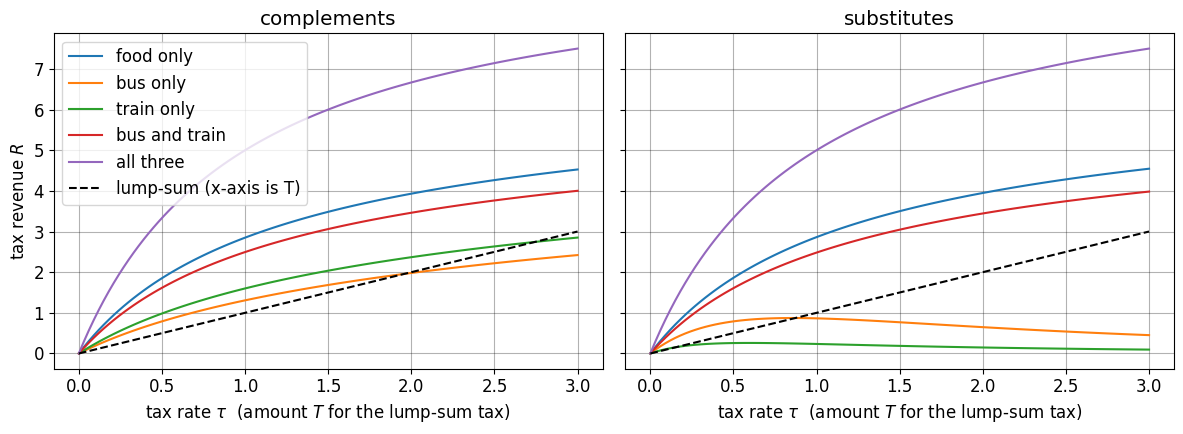

In [28]:
fig,axes = plt.subplots(1,2,figsize=(12,4.5),sharey=True)

for ax,name in zip(axes,results):
    # a. the five product taxes
    for label in instruments:
        ax.plot(tau_vec,results[name][label]['R'],label=label)

    # b. the lump-sum tax as a dashed reference line
    ax.plot(tau_vec,results[name]['lump-sum']['R'],ls='--',color='black',
            label='lump-sum (x-axis is T)')

    ax.set_title(name)
    ax.set_xlabel('tax rate $\\tau$  (amount $T$ for the lump-sum tax)')
    ax.grid(True,alpha=0.3)

axes[0].set_ylabel('tax revenue $R$')
axes[0].legend(loc='upper left')
fig.tight_layout()

In [29]:
# the same curves as numbers, at four rates, to read off in section 4.3
read_off = [0.5,1.0,2.0,3.0]
for name in results:
    rows = []
    for label in results[name]:
        row = {}
        row['instrument'] = label
        for tau in read_off:
            row[f'R(tau={tau})'] = np.interp(tau,tau_vec,results[name][label]['R'])
        rows.append(row)
    print(name)
    display(pd.DataFrame(rows).round(4))

complements


,instrument,R(tau=0.5),R(tau=1.0),R(tau=2.0),R(tau=3.0)
0,food only,1.8521,2.8493,3.9309,4.5261
1,bus only,0.7897,1.3069,1.9800,2.4206
2,train only,0.9831,1.5998,2.3685,2.8510
3,bus and train,1.6150,2.4947,3.4615,4.0019
4,all three,3.3327,4.9998,6.6666,7.5000
5,lump-sum,0.5000,1.0000,2.0000,3.0000


substitutes


,instrument,R(tau=0.5),R(tau=1.0),R(tau=2.0),R(tau=3.0)
0,food only,1.8607,2.8621,3.9477,4.5449
1,bus only,0.7895,0.8640,0.6475,0.4511
2,train only,0.2564,0.2341,0.1474,0.0953
3,bus and train,1.6063,2.4817,3.4441,3.9823
4,all three,3.3327,4.9998,6.6666,7.5000
5,lump-sum,0.5000,1.0000,2.0000,3.0000


What the two panels show. In the complements calibration all five curves rise
over the whole range 0 to 3  none of them has turned over yet. In the substitutes
calibration two of them clearly have a top: the tax on the bus alone peaks at
around `tau = 0.9` and then falls, and the tax on the train alone peaks much
earlier, at around `tau = 0.6`, and at a revenue barely above 0.25. Section 4.3
pins those numbers down; the figure is what tells us the grid there only has to
run out to about 3, not to 10.

Why the shapes differ. A product tax raises revenue `taup_jx_j`: the rate
pulls revenue up, the consumer's response pulls it down. Which one wins is
decided by how easily the consumer can get away from the taxed good.

 Food* is 54 percent of the budget, and the only substitute for it is travel,
  with `sigma_A = 0.80` in both calibrations. The consumer cannot escape, so the
  food curve is nearly identical in the two panels (4.5449 vs 4.5261 at
  `tau = 3`) and still rising at the end.
 Bus and train together* is the same story one level up: taxing both at the
  same rate leaves relative prices inside the travel nest unchanged, so
  `sigma_B` never gets to act. Only the inelastic upper nest is left, and the
  curve rises in both calibrations  3.98 vs 4.00 at `tau = 3`, again almost
  the same in the two calibrations even though `sigma_B` differs by a factor 7.5.
 Bus alone and train alone* are the only instruments that put a wedge
  inside the nest, and they are the only two curves that differ between the
  panels. With `sigma_B = 0.40` the consumer wants both kinds of travel and
  cannot substitute, so revenue keeps climbing. With `sigma_B = 3.00` the two are
  near-interchangeable, the consumer simply switches to the untaxed mode, and
  revenue collapses: a train tax at `tau = 3` raises only 0.095, less than half
  of what the same tax raises at `tau = 0.5`, and about 30 times less than under
  complements.
 All three at the same rate* is the flattest case of all: it lies on top of
  itself in the two panels, because it is a lump-sum tax in disguise, exactly as
  the check in 4.1 showed. It raises `tau/(1+tau)*I`  7.5 at `tau = 3`  and is
  the highest curve everywhere, but it is bounded above by income: no matter how
  high the rate, it can never raise more than `I = 10`.

The lump-sum reference. The dashed line is straight and unbounded, and it is
the only instrument for which that is true. It crosses the product-tax curves
somewhere in every panel, but the crossing is not the interesting comparison 
the curves are functions of different things. The comparison that matters is
utility at a given revenue, which is section 4.4.

A numerical remark. The uniform tax should give exactly `tau/(1+tau)*I`, and
at `tau = 0.5` the grid gives 3.3327 rather than 3.3333. The gap is L-BFGS-B
stopping at its default tolerance, not economics  it is the same effect measured
in section 2.2.4. It is far too small to matter for anything in this section.

### 4.3 Where are the tops, and how high are they?

A product tax raises `taup_jx_j`. The rate pushes revenue up and the consumer's
response pushes it down, so the curve has a top exactly when the second force
eventually wins. From the figure in 4.2 the two forces are clearly balanced
somewhere below `tau = 1` for the bus and the train in the substitutes
calibration, and nowhere at all in the range for the other curves.

`max_revenue()` puts numbers on this the same way section 2.1 solved the consumer's
problem: lay a grid over the tax rate, compute revenue in every point, keep the
best one. The figure in 4.2 tells us the grid only has to run to `tau = 3`  the
two tops are far inside that. The docstring gives us the diagnostic for the other
curves: if the answer comes back at `tau_max`, the curve was still rising when
the grid ran out, and there is no top in the range searched.

In [30]:
# a grid over the tax rate, exactly as in section 2.1. The range 0 to 3 is read
# off the figure in 4.2. If the answer comes back at tau_max, there was no top.
for name,model in gov.items():
    rows = []
    for label,goods in instruments.items():
        tau,R = model.max_revenue(goods,tau_max=3.0,N=301)
        row = {}
        row['instrument'] = label
        row['tau*'] = tau
        row['R_max'] = R
        row['interior top'] = not np.isclose(tau,3.0)
        rows.append(row)
    model.set_taxes()
    print(name)
    display(pd.DataFrame(rows).round(4))

complements


,instrument,tau*,R_max,interior top
0,food only,3.0,4.5261,False
1,bus only,3.0,2.4206,False
2,train only,3.0,2.8510,False
3,bus and train,3.0,4.0019,False
4,all three,3.0,7.5000,False


substitutes


,instrument,tau*,R_max,interior top
0,food only,3.00,4.5449,False
1,bus only,0.86,0.8721,True
2,train only,0.59,0.2590,True
3,bus and train,3.00,3.9823,False
4,all three,3.00,7.5000,False


In [31]:
# for the curves that were still rising at tau = 3, widen the search a lot.
# if the answer is still at the edge, the curve keeps rising over the whole range.
for name,model in gov.items():
    for label,goods in instruments.items():
        tau,R = model.max_revenue(goods,tau_max=10.0,N=201)
        print(f'{name:12s} {label:14s} tau*={tau:6.3f}, R_max={R:.4f}, '
              f'at the edge={np.isclose(tau,10.0)}')
    model.set_taxes()

complements  food only      tau*=10.000, R_max=5.9159, at the edge=True


complements  bus only       tau*=10.000, R_max=3.7524, at the edge=True


complements  train only     tau*=10.000, R_max=4.2160, at the edge=True


complements  bus and train  tau*=10.000, R_max=5.3038, at the edge=True


complements  all three      tau*=10.000, R_max=9.0909, at the edge=True


substitutes  food only      tau*=10.000, R_max=5.9375, at the edge=True


substitutes  bus only       tau*= 0.850, R_max=0.8721, at the edge=False


substitutes  train only     tau*= 0.600, R_max=0.2590, at the edge=False


substitutes  bus and train  tau*=10.000, R_max=5.2807, at the edge=True


substitutes  all three      tau*=10.000, R_max=9.0909, at the edge=True


In [32]:
# push the rate far beyond anything sensible, to see what the curves converge to
for name,model in gov.items():
    rows = []
    for label,goods in instruments.items():
        row = {}
        row['instrument'] = label
        for tau in [3.0,10.0,100.0,1000.0]:
            R,u = model.revenue_and_utility(tau,goods)
            row[f'R(tau={tau:g})'] = R
        rows.append(row)
    model.set_taxes()
    print(name)
    display(pd.DataFrame(rows).round(4))

complements


,instrument,R(tau=3),R(tau=10),R(tau=100),R(tau=1000)
0,food only,4.5261,5.9159,7.3643,8.2037
1,bus only,2.4206,3.7524,5.7749,7.1037
2,train only,2.8510,4.2160,6.1002,7.3099
3,bus and train,4.0019,5.3038,6.7895,7.7461
4,all three,7.5000,9.0909,9.9010,9.9900


substitutes


,instrument,R(tau=3),R(tau=10),R(tau=100),R(tau=1000)
0,food only,4.5449,5.9375,7.3840,8.2190
1,bus only,0.4511,0.0814,0.0011,0.0000
2,train only,0.0953,0.0157,0.0002,0.0000
3,bus and train,3.9823,5.2807,6.7672,7.7279
4,all three,7.5000,9.0909,9.9010,9.9900


In [33]:
# the same question as in section 2.1.3, now for the tax rate: how much does the
# answer move when the grid gets finer, and what does the extra precision buy?
model = gov['substitutes']
rows = []
for label,goods in [('bus only',(2,)),('train only',(3,))]:
    for N_tau in [31,101,301,1001]:
        tau,R = model.max_revenue(goods,tau_max=3.0,N=N_tau)
        row = {}
        row['instrument'] = label
        row['N'] = N_tau
        row['tau*'] = tau
        row['R_max'] = R
        rows.append(row)
model.set_taxes()
display(pd.DataFrame(rows).round(6))

,instrument,N,tau*,R_max
0,bus only,31,0.900,0.871306
1,bus only,101,0.870,0.872055
2,bus only,301,0.860,0.872136
3,bus only,1001,0.855,0.872144
4,train only,31,0.600,0.259027
5,train only,101,0.600,0.259027
6,train only,301,0.590,0.259037
7,train only,1001,0.594,0.259039


Which curves have a top. Only two of the ten: the tax on the bus alone and
the tax on the train alone, and only in the substitutes calibration.

| | rate `tau*` | largest revenue `R_max` |
|---|---|---|
| bus only, substitutes | 0.86 | 0.8721 |
| train only, substitutes | 0.59 | 0.2590 |

Everything else is still rising at `tau = 3`, and widening the grid to `tau = 10`
does not change that: the answer comes back at the edge every time. The two tops
in the substitutes calibration are unchanged by the wider grid  0.8721 at 0.85
and 0.2590 at 0.60  so they are genuine maxima and not an artifact of where we
stopped looking.

Why only those two. A top appears when the consumer has somewhere to escape
to. The bus and the train are near-perfect substitutes when `sigma_B = 3`, so
taxing one of them alone lets the consumer move to the other, and past a certain
rate the shrinking quantity outweighs the rising rate. Every other instrument
closes that door: taxing bus and train at the same rate leaves the relative price
inside the nest untouched, taxing food alone leaves only the inelastic upper nest
(`sigma_A = 0.80`) to substitute across, and taxing all three at the same rate is
a lump-sum tax in disguise. Under complements, `sigma_B = 0.40` means the consumer
wants bus and train together and cannot swap one for the other, so even a tax on
one mode alone keeps raising more.

Rising is not the same as unbounded. The extreme-rate table shows what the
rising curves converge to. Under complements they all climb towards income
itself  at `tau = 1000` a tax on food alone raises 8.20 and the uniform tax
raises 9.99  because when a good has no substitute, an extreme price makes it
absorb the whole budget, and the tax then takes almost all of it. Revenue can
never exceed `I = 10`; the curves approach that ceiling without ever having a top.
Under substitutes the two single-mode taxes do the opposite and go to zero: at
`tau = 1000` a train tax raises 0.0000, because the consumer has stopped taking
the train altogether. Same instrument, same rate, opposite outcome  the
elasticity is doing all the work.

The explicit answer. The most that a tax on train tickets alone can ever
raise in the substitutes calibration is 0.2590, or 2.6 percent of income, at a
rate of about 59 percent. That is a remarkably weak instrument: the train is only
9.5 percent of the budget to begin with, and the consumer's willingness to switch
to the bus caps the yield at a quarter of one train ticket. It matters directly in
section 4.5, where the government needs 0.20  which this instrument can just
barely reach, but only just, and the target sits close enough to the top that two
different rates raise it.

How fine does the grid need to be? Going from `N = 31` to `N = 1001` moves the
revenue-maximizing rate from 0.900 to 0.855 for the bus, but moves the largest
revenue from 0.8713 to 0.8721  a change in the fourth decimal for a thirtyfold
increase in cost. This is the same lesson as section 2.1.3, and it has an economic
reading too: the top of a revenue curve is flat, so the government loses almost
nothing by getting the rate slightly wrong. What is expensive is being on the
wrong side of the top  a rate of 2.0 on the train raises less than a rate of
0.2.

### 4.4 What does the revenue cost the consumer?

Revenue on its own says nothing about whether an instrument is good. Two taxes
that raise the same amount are compared by the utility the consumer is left with,
and higher is better. So we plot utility against revenue raised, with the tax rate
as the hidden parameter running along each curve.

All the numbers are already in `results` from 4.2: each instrument has an array of
revenues and an array of utilities, computed from the same solutions. Nothing new
has to be solved here.

One thing to be careful about when reading numbers off these curves. For the two
instruments with a top in 4.3, revenue is not one-to-one in the tax rate: every
revenue below the top is raised by two different rates, a low one and a high one,
and the high one leaves the consumer strictly worse off. Those curves therefore
double back on themselves in the figure. When we interpolate utility at a given
revenue below, we use only the rising branch  up to `np.argmax(R)`  because the
backward-bending branch is dominated and no government would ever choose it.

In [34]:
# read utility off each curve at the same four revenue levels, on the rising branch
levels = [0.2,0.5,1.0,2.0]
for name in results:
    rows = []
    for label in results[name]:
        R = results[name][label]['R']
        u = results[name][label]['u']

        # a. keep the rising branch only: up to and including the revenue maximum
        i = np.argmax(R)
        R_up = R[:i+1]
        u_up = u[:i+1]

        # b. interpolate utility at each target revenue, or np.nan if out of reach
        row = {}
        row['instrument'] = label
        for level in levels:
            if level <= R_up[-1]:
                row[f'u at R={level}'] = np.interp(level,R_up,u_up)
            else:
                row[f'u at R={level}'] = np.nan
        rows.append(row)

    print(name)
    display(pd.DataFrame(rows).round(6))

complements


,instrument,u at R=0.2,u at R=0.5,u at R=1.0,u at R=2.0
0,food only,3.333113,3.228508,3.048987,2.668315
1,bus only,3.332235,3.222821,3.025923,2.576279
2,train only,3.332519,3.224602,3.032934,2.601959
3,bus and train,3.332942,3.227531,3.044685,2.649005
4,all three,3.333646,3.231596,3.061512,2.721344
5,lump-sum,3.333646,3.231596,3.061512,2.721344


substitutes


,instrument,u at R=0.2,u at R=0.5,u at R=1.0,u at R=2.0
0,food only,3.414862,3.307720,3.123901,2.734361
1,bus only,3.412246,3.286222,NaN,NaN
2,train only,3.395475,NaN,NaN,NaN
3,bus and train,3.414674,3.306646,3.119173,2.713104
4,all three,3.415402,3.310849,3.136594,2.788084
5,lump-sum,3.415402,3.310849,3.136594,2.788084


In [35]:
# the difference asked for: uniform product tax vs lump-sum tax at the same revenue
for name in results:
    R_un = results[name]['all three']['R']
    u_un = results[name]['all three']['u']
    R_ls = results[name]['lump-sum']['R']
    u_ls = results[name]['lump-sum']['u']
    for level in levels:
        u_uniform = np.interp(level,R_un,u_un)
        u_lumpsum = np.interp(level,R_ls,u_ls)
        print(f'{name:12s} R={level}: u_uniform={u_uniform:.8f}, '
              f'u_lumpsum={u_lumpsum:.8f}, difference={u_uniform-u_lumpsum:.2e}')

complements  R=0.2: u_uniform=3.33364628, u_lumpsum=3.33364628, difference=-5.77e-15
complements  R=0.5: u_uniform=3.23159588, u_lumpsum=3.23159588, difference=-7.11e-15
complements  R=1.0: u_uniform=3.06151189, u_lumpsum=3.06151189, difference=-2.22e-14
complements  R=2.0: u_uniform=2.72134390, u_lumpsum=2.72134390, difference=-5.34e-12
substitutes  R=0.2: u_uniform=3.41540250, u_lumpsum=3.41540250, difference=-6.66e-15
substitutes  R=0.5: u_uniform=3.31084936, u_lumpsum=3.31084936, difference=9.33e-15
substitutes  R=1.0: u_uniform=3.13659413, u_lumpsum=3.13659413, difference=-4.00e-15
substitutes  R=2.0: u_uniform=2.78808367, u_lumpsum=2.78808367, difference=6.66e-15


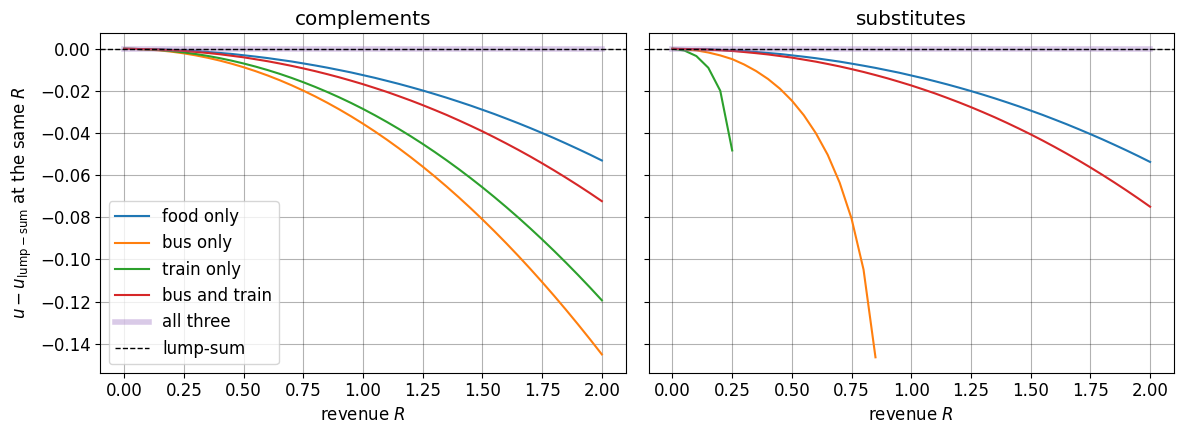

In [36]:
# the same comparison for every instrument, as a curve: how much utility is lost
# relative to a lump-sum tax raising exactly the same revenue
R_common = np.linspace(0.0,2.0,41)

fig,axes = plt.subplots(1,2,figsize=(12,4.5),sharey=True)
for ax,name in zip(axes,results):
    R_ls = results[name]['lump-sum']['R']
    u_ls = results[name]['lump-sum']['u']

    for label in instruments:
        R = results[name][label]['R']
        u = results[name][label]['u']
        i = np.argmax(R)
        R_up = R[:i+1]
        u_up = u[:i+1]

        # a. the gap at each common revenue level, np.nan where unreachable
        gap = np.zeros(len(R_common))
        for k,level in enumerate(R_common):
            if level <= R_up[-1]:
                gap[k] = np.interp(level,R_up,u_up) - np.interp(level,R_ls,u_ls)
            else:
                gap[k] = np.nan

        if label == 'all three':
            ax.plot(R_common,gap,lw=4,alpha=0.35,label=label)
        else:
            ax.plot(R_common,gap,label=label)

    ax.axhline(0,color='black',ls='--',lw=1,label='lump-sum')
    ax.set_title(name)
    ax.set_xlabel('revenue $R$')
    ax.grid(True,alpha=0.3)

axes[0].set_ylabel('$u - u_{\\mathrm{lump-sum}}$ at the same $R$')
axes[0].legend(loc='lower left')
fig.tight_layout()

The ranking. The natural yardstick is the utility lost relative to a lump-sum
tax raising exactly the same revenue. Zero is best, and more negative is worse.

| Instrument | complements, R=0.2 | complements, R=1.0 | substitutes, R=0.2 | substitutes, R=1.0 |
|---|---|---|---|---|
| lump-sum | 0.000000 | 0.000000 | 0.000000 | 0.000000 |
| all three | 0.000000 | 0.000000 | 0.000000 | 0.000000 |
| food only | -0.000533 | -0.012525 | -0.000540 | -0.012693 |
| bus and train | -0.000704 | -0.016827 | -0.000728 | -0.017422 |
| train only | -0.001128 | -0.028578 | -0.019928 | out of reach |
| bus only | -0.001412 | -0.035589 | -0.003157 | out of reach |

The rows are ordered by the complements column, and the top four places hold in
both calibrations. One principle explains the whole order: the broader the base
and the harder it is for the consumer to escape, the cheaper the revenue. A tax on
all three goods is the broadest base there is and costs nothing at all. Food is
the largest single base  54 percent of spending in both calibrations  and its
only substitute is travel, across the inelastic upper nest. Bus and train together
is a smaller base at 46 percent, but taxing both at one rate leaves the relative
price inside the travel nest untouched, so it distorts in one dimension rather
than two. The two single-mode taxes distort inside the nest as well as across it,
and they sit at the bottom.

Where the ranking depends on the calibration. The last two rows swap. Under
complements, the train is the larger of the two travel bases  26 percent of
spending against the bus's 20  so a train tax needs a lower rate for the same
revenue and does less damage. Under substitutes the shares reverse to 14 percent
for the train and 32 for the bus, and on top of the smaller base the consumer is
now willing to switch modes. Both effects push the same way, and the train tax
becomes by far the worst instrument in the model: at R=0.2 it costs 37 times as
much utility as a food tax, where the bus tax costs about 6 times as much. The
ordering of the two narrow taxes is therefore not a property of the instruments.
It is a property of the consumer.

A uniform product tax is a lump-sum tax. The difference `u_uniform - u_lumpsum`
is not merely small, it is zero: around 1e-14 at every revenue level in both
calibrations, which is machine precision. That is not a numerical accident. A
uniform rate `tau` multiplies all three prices by `(1+tau)`, so the consumer can
afford `I/(1+tau)` in real terms. Revenue is `tau/(1+tau)*I`, so real income after
the tax is exactly `I-R`  precisely what a lump-sum tax of `R` leaves behind.
Relative prices never move, the consumer never substitutes, and there is nothing
to distort. This works here because our consumer has no untaxed alternative: no
leisure, no saving, nothing outside the three goods. A uniform tax on everything
is a tax on income. The welfare loss from using product taxes rather than a
lump-sum tax is therefore exactly zero for the uniform tax, and strictly positive
for every instrument that hits some goods and not others.

The shape of the loss. The gap curves start flat and then steepen. Multiplying
the revenue by five, from 0.2 to 1.0, multiplies the loss by roughly 25 for every
instrument in the table  the welfare cost grows about with the square of the
revenue raised, while revenue itself grows less than proportionally with the rate.
Small taxes are nearly free; the last krone raised is always the most expensive.

The backward bend. In the substitutes panel of the first figure the bus and
train curves loop back on themselves. Past the revenue maximum found in 4.3, the
consumer keeps losing utility while the government collects less. Every point on
that returning branch is dominated by a point on the rising branch with the same
revenue and higher utility, which is why the table above interpolates on the
rising branch only. It is the clearest possible picture of a tax rate that is
simply too high  and it is exactly the complication section 4.5 has to handle,
since a root-finder does not know which of two roots we want.

### 4.5 Hitting a given revenue requirement

The government needs `R = 0.20`, i.e. 2 percent of income. For each instrument we
want the tax rate that raises exactly that. This is a root-finding problem:
`f(tau) = R(tau) - 0.20`, and we want `f(tau) = 0`. `find_tax_rate()` builds that
`f` and hands it to `optimize.root_scalar` with `method='brentq'`.

Brent's method needs a bracket: two rates where `f` has opposite signs. At
`tau = 0` revenue is zero, so `f` starts negative, and if the instrument can reach
the target then `f` turns positive somewhere. The default bracket is
`(1e-10, 1.0)`. The left end is not zero but a hair above it, because `tau = 0`
would make `f` exactly `-R_target` and a zero-width sign change is fragile; the
right end has to be far enough out that `f` has actually turned positive.

This is the one place in the whole project where a `try/except` is warranted. From
4.3 we know revenue is not monotone: an instrument has a ceiling, and a target
above it cannot be reached at any rate. Then `f` never changes sign, `brentq`
raises a `ValueError`, and that is the correct answer rather than a bug 
`find_tax_rate()` catches it and returns `np.nan`.

In [37]:
# the revenue requirement: 2 percent of income
R_target = 0.20

for name,model in gov.items():
    # a. the lump-sum benchmark first, so every instrument can be measured against it
    R_ls,u_ls = model.revenue_and_utility_lump_sum(R_target)
    model.set_taxes()

    rows = []
    for label,goods in instruments.items():
        # b. the rate that raises exactly R_target, or np.nan if unreachable
        tau = model.find_tax_rate(R_target,goods,bracket=(1e-10,1.0))

        row = {}
        row['instrument'] = label
        if np.isnan(tau):
            row['tau'] = np.nan
            row['R'] = np.nan
            row['u'] = np.nan
            row['u - u_lumpsum'] = np.nan
        else:
            # c. check what that rate actually raises, and what it leaves the consumer
            R,u = model.revenue_and_utility(tau,goods)
            row['tau'] = tau
            row['R'] = R
            row['u'] = u
            row['u - u_lumpsum'] = u - u_ls
        rows.append(row)

    # d. the lump-sum row, where the number in the tau column is an amount T
    rows.append({'instrument':'lump-sum','tau':R_target,'R':R_ls,'u':u_ls,
                 'u - u_lumpsum':0.0})

    model.set_taxes()
    print(name)
    display(pd.DataFrame(rows).round(6))

complements


,instrument,tau,R,u,u - u_lumpsum
0,food only,0.038647,0.2,3.333169,-0.000477
1,bus only,0.104215,0.2,3.332260,-0.001386
2,train only,0.081011,0.2,3.332548,-0.001099
3,bus and train,0.044787,0.2,3.333010,-0.000636
4,all three,0.020408,0.2,3.333646,-0.000000
5,lump-sum,0.200000,0.2,3.333646,0.000000


substitutes


,instrument,tau,R,u,u - u_lumpsum
0,food only,0.038454,0.2,3.414919,-0.000484
1,bus only,0.069532,0.2,3.412375,-0.003028
2,train only,0.236217,0.2,3.395521,-0.019881
3,bus and train,0.045049,0.2,3.414744,-0.000659
4,all three,0.020408,0.2,3.415402,-0.000000
5,lump-sum,0.200000,0.2,3.415402,0.000000


In [38]:
# the train tax in the substitutes calibration has two rates raising 0.20, one on
# each side of the revenue maximum found in 4.3. Which one brentq returns -- or
# whether it returns anything at all -- is decided entirely by the bracket.
model = gov['substitutes']
for bracket in [(1e-10,1.0),(1e-10,0.5),(1e-10,3.0),(0.6,3.0),(1.0,3.0)]:
    tau = model.find_tax_rate(R_target,(3,),bracket=bracket)
    if np.isnan(tau):
        print(f'bracket={str(bracket):16s} -> no root found')
    else:
        R,u = model.revenue_and_utility(tau,(3,))
        print(f'bracket={str(bracket):16s} -> tau={tau:.6f}, R={R:.6f}, u={u:.6f}')
model.set_taxes()

bracket=(1e-10, 1.0)     -> tau=0.236217, R=0.200000, u=3.395521
bracket=(1e-10, 0.5)     -> tau=0.236217, R=0.200000, u=3.395521
bracket=(1e-10, 3.0)     -> no root found


bracket=(0.6, 3.0)       -> tau=1.357219, R=0.200000, u=3.257095


bracket=(1.0, 3.0)       -> tau=1.357219, R=0.200000, u=3.257095


In [39]:
# raise the target above what a train tax can ever raise in this calibration
model = gov['substitutes']
for target in [0.20,0.259,0.26,0.30]:
    tau = model.find_tax_rate(target,(3,),bracket=(1e-10,1.0))
    print(f'target R={target:.3f}: tau={tau}')
model.set_taxes()

# for reference, the ceiling from 4.3
tau_star,R_max = model.max_revenue((3,),tau_max=3.0,N=301)
model.set_taxes()
print(f'the train tax can never raise more than {R_max:.4f}, at tau={tau_star:.2f}')

target R=0.200: tau=0.2362174074750554
target R=0.259: tau=nan
target R=0.260: tau=nan
target R=0.300: tau=nan


the train tax can never raise more than 0.2590, at tau=0.59


The rates. All five instruments can reach 2 percent of income in both
calibrations, and the rate each one needs is itself informative.

| Instrument | tau, complements | u - u_lumpsum | tau, substitutes | u - u_lumpsum |
|---|---|---|---|---|
| all three | 0.020408 | -0.000000 | 0.020408 | -0.000000 |
| food only | 0.038647 | -0.000477 | 0.038454 | -0.000484 |
| bus and train | 0.044787 | -0.000636 | 0.045049 | -0.000659 |
| train only | 0.081011 | -0.001099 | 0.236217 | -0.019881 |
| bus only | 0.104215 | -0.001386 | 0.069532 | -0.003028 |
| lump-sum (T) | 0.200000 | 0.000000 | 0.200000 | 0.000000 |

Every row raises exactly 0.20 by construction, so the columns that matter are the
rate and the utility left behind. The ranking is the same one section 4.4 found at
this revenue level, which is a good consistency check: the two sections compute it
in completely different ways  4.4 interpolates along a curve, 4.5 solves for the
rate directly  and they agree to six decimals.

Reading the rates. The uniform tax needs only 2.04 percent, and that number is
exact: a uniform rate raises `tau/(1+tau)*I`, so hitting `R` requires
`tau = R/(I-R) = 0.2/9.8 = 0.020408`. It is the lowest rate on the list because it
has the broadest base  all of income. Food needs 3.86 percent on a base of 54
percent of spending, bus and train 4.5 percent on 46 percent. The two narrow taxes
need much more, and the ordering flips between the calibrations exactly as in 4.4.

The train tax. This is the instrument worth dwelling on. Under complements it
needs a rate of 8.1 percent and costs the consumer 0.0011 in utility. Under
substitutes the same 0.20 requires a rate of 23.6 percent  nearly three times
as high  and costs 0.0199, which is 41 times the cost of raising the same money
through a tax on food. The reason is the ceiling from 4.3: this instrument can
never raise more than 0.2590, so a target of 0.20 is already 77 percent of
everything it will ever be able to collect. The government is operating near the
top of the Laffer curve, where each extra krone requires a large jump in the rate
and drives the consumer further onto the bus. A tax base that the taxpayer can walk
away from is a bad tax base, and this is what that looks like in numbers.

Two roots, one of them a trap. Because revenue is not monotone, 0.20 is raised
at two rates in the substitutes calibration: `tau = 0.2362`, which leaves utility
3.3955, and `tau = 1.3572`, which leaves 3.2571. Both are correct roots of
`f(tau) = 0`. The high one costs the consumer 0.1384 more utility  seven times the
entire distortion of the low root  for exactly the same revenue, and no government
would choose it. The bracket experiment shows how easily a root-finder hands you
the wrong one, or nothing at all:

* `(1e-10, 1.0)` and `(1e-10, 0.5)` both return 0.2362, the root we want. The
  interval contains exactly one sign change.
* `(1e-10, 3.0)` returns `np.nan`. This looks like failure but is not a bug: at
  `tau = 3` revenue has fallen back to 0.095, below the target, so `f` is negative
  at both ends. Brent's method sees no sign change and refuses, even though there
  are two roots strictly inside the interval. A wider bracket is not a safer one.
* `(0.6, 3.0)` and `(1.0, 3.0)` return 1.3572  the dominated root, delivered
  without any warning that a better rate exists.

The lesson is that `bracket` is an economic choice, not a technical detail. It has
to be read off the revenue curve in 4.2: wide enough to contain the crossing, and
narrow enough to stop before the revenue maximum. Nothing in the return value of
`root_scalar` tells you which side of the peak you landed on.

When the target truly cannot be reached. Pushing the requirement up shows the
`try/except` doing its job. At `R = 0.26` the train tax in the substitutes
calibration returns `np.nan`, and it should: the ceiling is 0.2590, so no rate on
earth raises 0.26 from train tickets alone. The honest report is that the target is
infeasible for this instrument. `R = 0.259` also returns `np.nan` with the default
bracket, but for a different reason  that target is feasible, at `tau = 0.5809`,
but the root sits so close to the peak that revenue has already fallen back below
it by `tau = 1`, so the default bracket has negative `f` at both ends. The two
`np.nan`s look identical and mean different things, which is exactly why the
ceiling from `max_revenue()` should be checked before concluding that a target is
impossible.

Overall ranking, both calibrations. Lump-sum and the uniform product tax tie
for first at zero cost. Then food, then bus and train. The bottom two depend on the
consumer: under complements a bus tax is the worst instrument, under substitutes it
is the train tax, and by a much wider margin than any other gap in the table.

## 5. Extension: preference for food

As an extension, I investigate how the consumer's preference for food affects the response to changes in the train price.

In the baseline model, the preference weight on food is $\alpha=0.60$. A higher value of $\alpha$ means that food receives a larger weight in the upper CES nest, while a lower value means that travel receives a larger weight.

I consider three values of $\alpha$: $0.40$, $0.60$ and $0.80$. For each value, I vary the train price $p_3$ from 0.5 to 3.0, while keeping the other parameters fixed. I then compare how food and travel demand respond to changes in the train price.

This extension allows me to examine whether the effect of a change in the price of train travel depends on how strongly the consumer prefers food relative to travel.



In [40]:
# three calibrations with different preferences for food
model_a04 = ConsumerClass(par={'alpha':0.4})
model_a06 = ConsumerClass(par={'alpha':0.6})
model_a08 = ConsumerClass(par={'alpha':0.8})

models_alpha = {
    'alpha = 0.4': model_a04,
    'alpha = 0.6': model_a06,
    'alpha = 0.8': model_a08}

### 5.1 Varying the train price

I now vary the train price $p_3$ from 0.5 to 3.0 for each value of $\alpha$. The other prices, income and substitution parameters are kept at their baseline values.

For each combination of $\alpha$ and $p_3$, I solve the consumer's optimization problem and store the quantities of food, bus and train.


In [41]:
N = 100
p3_grid = np.linspace(0.5, 3.0, N)

# store quantities for each alpha
results_alpha = {}

for name, m in models_alpha.items():
    
    quants = np.zeros((N,3))
    
    for i, p3 in enumerate(p3_grid):
        m.par.p3 = p3
        o = m.solve(do_print=False)
        
        quants[i] = m.quantities(o.s1, o.w)
    
    # reset price to baseline
    m.par.p3 = 1.5
    
    results_alpha[name] = quants

print('done')

done


### 5.2 Food and travel demand

I first compare food demand across the three values of $\alpha$. Since $\alpha$ determines the weight placed on food in the upper nest, I expect food demand to become relatively more important as $\alpha$ increases.

I then compare bus and train demand to see whether the effect of a higher train price differs depending on the consumer's preference for food.


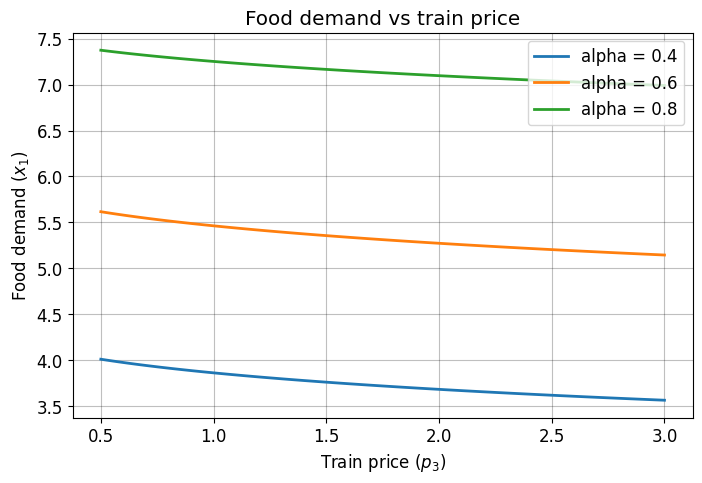

In [42]:
fig, ax = plt.subplots(figsize=(8,5))

for name, qt in results_alpha.items():
    ax.plot(p3_grid, qt[:,0], label=name, lw=2)

ax.set_xlabel('Train price ($p_3$)')
ax.set_ylabel('Food demand ($x_1$)')
ax.set_title('Food demand vs train price')
ax.legend()

plt.show()

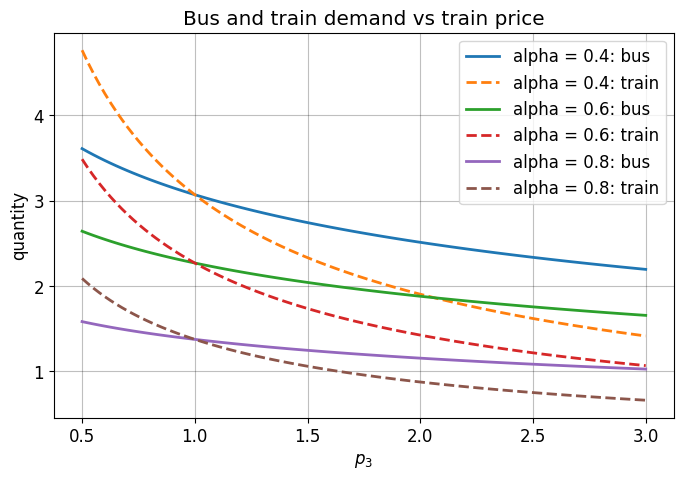

In [43]:
fig, ax = plt.subplots(figsize=(8,5))

for name, qt in results_alpha.items():
    ax.plot(p3_grid, qt[:,1], label=f'{name}: bus', lw=2)
    ax.plot(p3_grid, qt[:,2], '--', label=f'{name}: train', lw=2)

ax.set_xlabel('$p_3$')
ax.set_ylabel('quantity')
ax.set_title('Bus and train demand vs train price')
ax.legend()

plt.show()

### 5.3 Results

The results show that the preference for food affects how the consumer allocates income between food and travel.

When $\alpha$ is low, travel receives a relatively larger weight in the upper nest. The consumer therefore spends a larger part of the budget on travel. When $\alpha$ is high, food receives a larger weight, and the consumer allocates relatively more of the budget to food.

The response to an increase in the train price is therefore also affected by $\alpha$. A higher train price makes train travel more expensive, but the size of the resulting change in food and travel demand depends on how important travel is in the consumer's preferences.

The effect is particularly visible when comparing $\alpha=0.40$ with $\alpha=0.80$. With $\alpha=0.40$, travel is relatively important, so changes in the price of train travel have a larger effect on the allocation of the consumer's budget. With $\alpha=0.80$, food has a larger weight, so the consumer's allocation is less focused on travel.

Overall, the extension shows that the response to a price change does not only depend on the substitution possibilities between bus and train. It also depends on the consumer's preferences between the upper-level categories of food and travel.


In [44]:
print(f'{"alpha":>10} {"food change":>15} {"bus change":>15} {"train change":>17}')

for name, qt in results_alpha.items():
    dx1 = qt[-1,0] - qt[0,0]
    dx2 = qt[-1,1] - qt[0,1]
    dx3 = qt[-1,2] - qt[0,2]
    
    print(f'{name:>10} {dx1:>15.3f} {dx2:>15.3f} {dx3:>17.3f}')

     alpha     food change      bus change      train change
alpha = 0.4          -0.446          -1.414            -3.347
alpha = 0.6          -0.471          -0.986            -2.418
alpha = 0.8          -0.384          -0.556            -1.426


### 5.4 Conclusion

The extension shows that the consumer's preference structure matters for the response to a price change.

Changing $\alpha$ changes the relative importance of food and travel in the consumer's utility function. Consequently, the same increase in the train price can lead to different changes in food, bus and train demand depending on the value of $\alpha$.

This extends the analysis from section 3 by showing that the effect of a relative price change depends not only on substitution between bus and train, but also on the consumer's preferences between food and travel.
